<a href="https://colab.research.google.com/github/RonildoNascimento/recomendador-de-filmes/blob/main/Recomendador_de_Filmes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Recomendador de Filmes
## Matemática para Inteligência Artificial

**Temas:** vetores, matrizes, transformações lineares, SVD, derivadas,
integrais, gradiente descendente e métodos numéricos.

Este projeto explora conceitos matemáticos fundamentais utilizados em
Inteligência Artificial por meio da construção e análise de um sistema
de recomendação de filmes.

In [1]:
# ============================================
# CONFIGURAÇÃO DO PROJETO
# ============================================

AUTOR = "Ronildo Batista do Nascimento"

import numpy as np
import matplotlib.pyplot as plt

# Semente fixa para garantir resultados reproduzíveis
SEMENTE = 123456
np.random.seed(SEMENTE)

print(f"Projeto: Recomendador de Filmes")
print(f"Autor: {AUTOR}")
print(f"Semente utilizada: {SEMENTE}")

Projeto: Recomendador de Filmes
Autor: Ronildo Batista do Nascimento
Semente utilizada: 123456


---
# Parte 0 — Fundamentos com NumPy 🔥

Nesta etapa são demonstradas operações fundamentais com vetores utilizando NumPy, incluindo soma, multiplicação elemento a elemento, produto interno e cálculo da norma.

In [2]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("Soma:            ", a + b)
print("Multiplicação:   ", a * b)          # elemento a elemento
print("Produto interno: ", np.dot(a, b))   # 1*4 + 2*5 + 3*6 = 32
print("Norma (tamanho): ", np.linalg.norm(a))

Soma:             [5 7 9]
Multiplicação:    [ 4 10 18]
Produto interno:  32
Norma (tamanho):  3.7416573867739413


Produto Interno entre Vetores
Como demonstração, é calculado o produto interno entre os vetores a e c. Essa operação será posteriormente importante para medir a similaridade entre vetores no sistema de recomendação.

In [3]:
# Vetor utilizado na demonstração
c = np.array([2, 0, 1])

# Produto interno entre os vetores a e c
produto = np.dot(a, c)

print("Produto interno a·c =", produto)

Produto interno a·c = 5


---
Vetores e Similaridade entre Usuários 🤝

O sistema de recomendação utiliza uma matriz de avaliações, na qual cada linha representa um usuário, cada coluna representa um filme e cada valor corresponde a uma nota de 0 a 5. O valor 0 indica que o filme ainda não foi assistido.

| | Matrix | Titanic | Toy Story | Vingadores | Barbie |
|---|---|---|---|---|---|
| **Ana** | 5 | 1 | 2 | 5 | 1 |
| **Bruno** | 4 | 0 | 1 | 5 | 2 |
| **Carla** | 1 | 5 | 4 | 1 | 5 |
| **Davi** | 0 | 4 | 5 | 2 | 4 |
| **Você** | 5 | 2 | 1 | **0** | 1 |

No exemplo, o usuário “Você” ainda não assistiu ao filme Vingadores, representado pelo valor 0. O objetivo do sistema será utilizar o padrão de avaliações dos demais usuários para apoiar a recomendação desse filme.

Cada usuário pode ser representado como um vetor no espaço dos filmes. Usuários com padrões de avaliação semelhantes tendem a possuir vetores com direções próximas. Essa relação pode ser medida utilizando a similaridade por cosseno:

$$\text{sim}(\vec{u}, \vec{v}) = \cos(\theta) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \, \|\vec{v}\|}$$

- Resultado **perto de 1** → gostos muito parecidos
- Resultado **perto de 0** → gostos sem relação

In [4]:
filmes = ["Matrix", "Titanic", "Toy Story", "Vingadores", "Barbie"]
usuarios = ["Ana", "Bruno", "Carla", "Davi", "Você"]

R = np.array([
    [5, 1, 2, 5, 1],   # Ana
    [4, 0, 1, 5, 2],   # Bruno
    [1, 5, 4, 1, 5],   # Carla
    [0, 4, 5, 2, 4],   # Davi
    [5, 2, 1, 0, 1],   # Você  (0 em Vingadores = não assistiu)
], dtype=float)

print("Formato da matriz (linhas, colunas):", R.shape)
print("Vetor do usuário 'Você':", R[4])

Formato da matriz (linhas, colunas): (5, 5)
Vetor do usuário 'Você': [5. 2. 1. 0. 1.]


Cálculo da Similaridade por Cosseno
A função abaixo calcula a similaridade entre dois usuários a partir do produto interno de seus vetores de avaliações e de suas respectivas normas. Em seguida, a similaridade do usuário de referência é comparada com a dos demais usuários.

In [6]:
def similaridade_cosseno(u, v):
    # Produto interno entre os vetores
    numerador = np.dot(u, v)

    # Produto das normas dos vetores
    denominador = np.linalg.norm(u) * np.linalg.norm(v)

    # Evita divisão por zero
    if denominador == 0:
        return 0.0

    return numerador / denominador


# Similaridade do usuário de referência com os demais usuários
voce = R[4]

for i, nome in enumerate(usuarios[:4]):
    s = similaridade_cosseno(voce, R[i])
    print(f"Similaridade Você × {nome}: {s:.3f}")

Similaridade Você × Ana: 0.720
Similaridade Você × Bruno: 0.609
Similaridade Você × Carla: 0.523
Similaridade Você × Davi: 0.391


### 📊 Análise dos Resultados

A comparação por similaridade de cosseno indica que **Ana apresenta o padrão de avaliações mais semelhante ao usuário de referência**, com similaridade aproximada de **0,720**.

Na matriz de avaliações, Ana atribuiu nota **5 ao filme Vingadores**, enquanto o usuário de referência ainda não avaliou esse filme. Esse resultado sugere que *Vingadores* pode ser um candidato à recomendação com base na preferência do usuário mais semelhante.

### ⚠️ Limitação do Modelo

Nesta implementação, o valor `0` representa um filme **não assistido**. Entretanto, ao calcular diretamente a similaridade por cosseno, esse zero participa do vetor como um valor numérico.

Isso pode distorcer a medida de similaridade, pois o algoritmo não distingue automaticamente **“não assistiu”** de uma avaliação extremamente baixa.

Uma abordagem mais adequada seria calcular a similaridade considerando apenas os filmes avaliados por ambos os usuários ou utilizar uma representação específica para valores ausentes, como `NaN`, acompanhada de uma estratégia apropriada de tratamento.

Essa limitação demonstra a importância do pré-processamento dos dados em sistemas de recomendação.

---
Transformações Lineares com Matrizes 🌀

Uma matriz pode representar uma transformação linear aplicada a um vetor, permitindo operações geométricas como rotação, escala e reflexão.
Esse conceito também está relacionado ao funcionamento de modelos de Inteligência Artificial, nos quais os dados passam por sucessivas transformações lineares.
Para uma rotação por um ângulo \(\theta\), utiliza-se a seguinte matriz:

A matriz de **rotação** por um ângulo $\theta$ é:

$$M_{rot} = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

A demonstração abaixo aplica uma rotação de 45° a um conjunto de pontos bidimensionais em formato de seta, permitindo visualizar geometricamente o efeito da transformação.

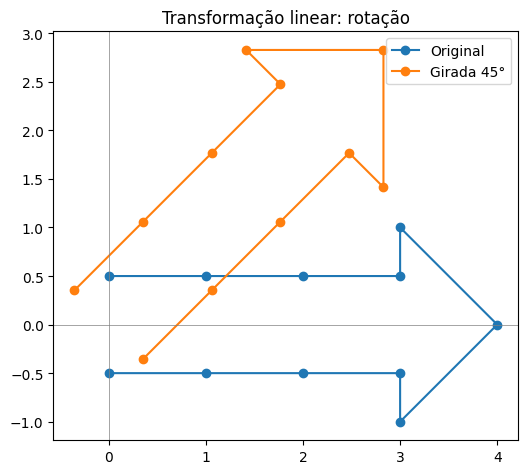

In [7]:
# Uma "seta" feita de pontos 2D (cada coluna é um ponto)
seta = np.array([
    [0, 1, 2, 3, 3, 4, 3, 3, 2, 1, 0],
    [0.5, 0.5, 0.5, 0.5, 1, 0, -1, -0.5, -0.5, -0.5, -0.5]
])

def matriz_rotacao(graus):
    t = np.radians(graus)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

# Matriz de rotação de 45 graus
M = matriz_rotacao(45)

# Aplicação da transformação linear aos pontos da seta
seta_girada = M @ seta

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(seta[0], seta[1], 'o-', label="Original")
ax.plot(seta_girada[0], seta_girada[1], 'o-', label="Girada 45°")
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title("Transformação linear: rotação")
plt.show()

Escala e Compressão com Transformações Lineares

A matriz abaixo aplica fatores de escala diferentes aos eixos x e y. O objetivo é visualizar como uma transformação linear pode alterar as proporções geométricas de um conjunto de pontos.

$$M_2 = \begin{bmatrix} 2 & 0 \\ 0 & 0.5 \end{bmatrix}$$

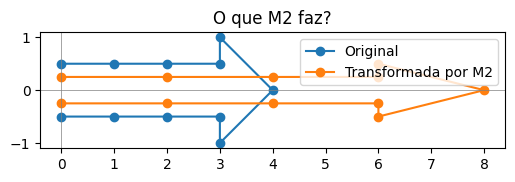

In [8]:
# Matriz de transformação:
# x é ampliado por um fator 2
# y é reduzido por um fator 0.5
M2 = np.array([
    [2, 0],
    [0, 0.5]
])

# Aplicação da transformação à seta original
seta_2 = M2 @ seta

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(seta[0], seta[1], 'o-', label="Original")
ax.plot(seta_2[0], seta_2[1], 'o-', label="Transformada por M2")
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title("O que M2 faz?")
plt.show()

### 📊 Análise da Transformação

A matriz \(M_2\) aplica fatores de escala diferentes em cada eixo:

- no eixo **x**, as coordenadas são multiplicadas por **2**, provocando um alongamento horizontal;
- no eixo **y**, as coordenadas são multiplicadas por **0,5**, reduzindo a dimensão vertical pela metade.

Como resultado, a seta mantém sua estrutura básica, mas passa por uma transformação de escala não uniforme: fica **mais larga horizontalmente e comprimida verticalmente**.

Esse exemplo demonstra como matrizes podem modificar a representação geométrica dos dados por meio de transformações lineares.

---
Decomposição SVD e Identificação de Padrões Latentes 🔍

A Decomposição em Valores Singulares (SVD) permite decompor uma matriz em três componentes:
\[
R = U\Sigma V^T
\]
Em sistemas de recomendação, essa técnica pode ser utilizada para identificar fatores latentes presentes nas avaliações dos usuários. Esses fatores representam padrões que não estão explicitamente registrados nos dados, mas podem refletir características como preferência por determinados gêneros ou estilos de filmes.
Os valores singulares, presentes em \(\Sigma\), ajudam a indicar a importância relativa desses fatores na representação da matriz de avaliações.
Para demonstrar esse conceito, será utilizada uma matriz sintética de avaliações contendo 20 usuários e 8 filmes, construída com dois padrões latentes principais: preferência por ação e preferência por drama.

Notas de 3 fãs de ação (usuários 0-2):
[[0.8 1.  0.  1.4 0.5 1.  0.  0.5]
 [1.  1.9 0.8 1.  0.  0.3 0.5 0.1]
 [0.8 2.8 1.4 1.8 0.3 0.  0.5 0. ]]

Notas de 3 fãs de drama (usuários 10-12):
[[0.9 0.9 0.1 0.8 0.  0.9 0.  0.9]
 [0.8 0.6 0.1 0.5 0.2 1.9 0.5 2. ]
 [0.  0.5 0.3 0.4 0.4 0.  0.5 0.2]]

(colunas 0-3 = filmes de ação | colunas 4-7 = filmes de drama)


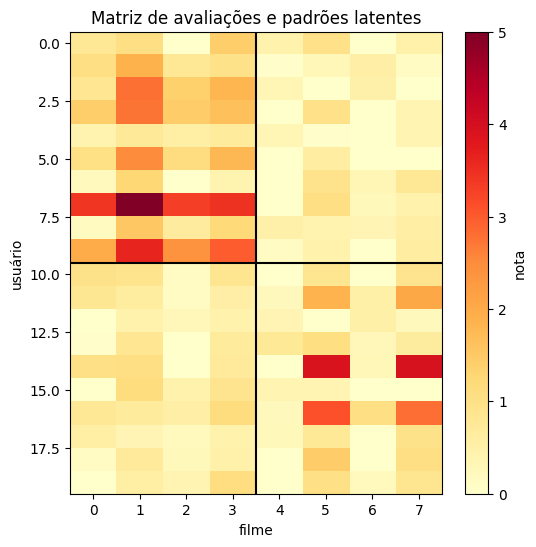

In [9]:
# Matriz sintética de avaliações: 20 usuários × 8 filmes
# Dois fatores latentes são utilizados na geração dos dados:
# fator 0 = AÇÃO | fator 1 = DRAMA
n_usuarios, n_filmes = 20, 8

# Preferências latentes dos usuários
gosto_usuarios = np.random.rand(n_usuarios, 2)
gosto_usuarios[:10, 1] *= 0.15
gosto_usuarios[10:, 0] *= 0.15

# Características latentes dos filmes
gosto_filmes = np.random.rand(2, n_filmes)
gosto_filmes[1, :4] *= 0.15
gosto_filmes[0, 4:] *= 0.15

# Construção da matriz sintética de avaliações
R_grande = gosto_usuarios @ gosto_filmes
R_grande = 5 * R_grande / R_grande.max()

# Adição de ruído para simular variações nas avaliações
R_grande += np.random.normal(0, 0.3, R_grande.shape)
R_grande = np.clip(R_grande, 0, 5)

print("Notas de 3 fãs de ação (usuários 0-2):")
print(np.round(R_grande[:3], 1))

print("\nNotas de 3 fãs de drama (usuários 10-12):")
print(np.round(R_grande[10:13], 1))

print("\n(colunas 0-3 = filmes de ação | colunas 4-7 = filmes de drama)")

plt.figure(figsize=(6, 6))
plt.imshow(R_grande, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="nota")
plt.axvline(3.5, color="black", lw=1.5)
plt.axhline(9.5, color="black", lw=1.5)
plt.xlabel("filme")
plt.ylabel("usuário")
plt.title("Matriz de avaliações e padrões latentes")
plt.show()

Valores singulares: [13.43  7.18  1.9   1.24  1.17  0.99  0.82  0.62]
Energia explicada (%): [75.  21.5  1.5  0.6  0.6  0.4  0.3  0.2]
Energia acumulada (%): [ 75.   96.5  98.   98.6  99.2  99.6  99.8 100. ]


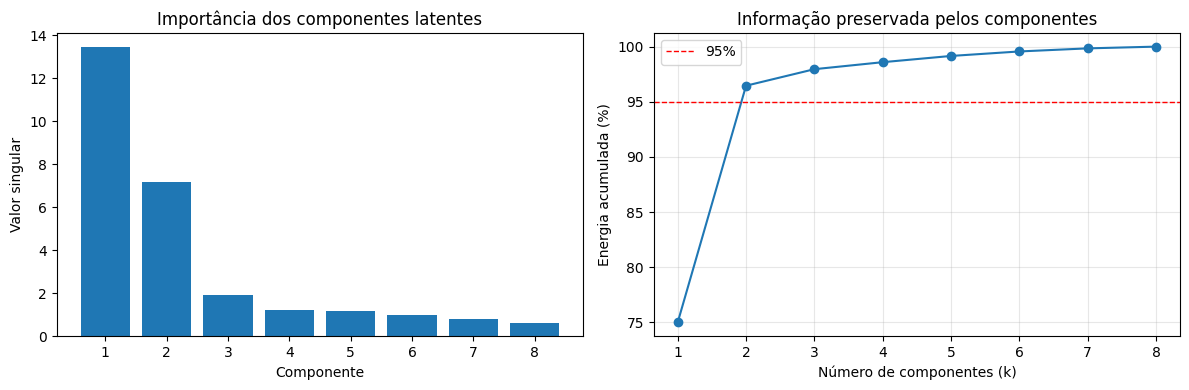

In [10]:
# Decomposição da matriz de avaliações por SVD
U, S, Vt = np.linalg.svd(R_grande, full_matrices=False)

# Proporção da informação representada por cada componente
energia = S**2 / np.sum(S**2)

print("Valores singulares:", np.round(S, 2))
print("Energia explicada (%):", np.round(100 * energia, 1))
print("Energia acumulada (%):", np.round(100 * np.cumsum(energia), 1))

# Visualização dos valores singulares e da energia acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(S) + 1), S)
ax1.set_xlabel("Componente")
ax1.set_ylabel("Valor singular")
ax1.set_title("Importância dos componentes latentes")

ax2.plot(
    range(1, len(S) + 1),
    100 * np.cumsum(energia),
    "o-"
)

ax2.axhline(
    95,
    color="red",
    linestyle="--",
    linewidth=1,
    label="95%"
)

ax2.set_xlabel("Número de componentes (k)")
ax2.set_ylabel("Energia acumulada (%)")
ax2.set_title("Informação preservada pelos componentes")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análise dos Resultados da SVD

Os resultados mostram uma forte concentração da informação nos primeiros componentes da decomposição.

O **primeiro componente** representa aproximadamente **75,0%** da energia total da matriz, enquanto o **segundo componente** representa cerca de **21,5%**.

Juntos, os dois primeiros componentes preservam aproximadamente **96,5% da informação** presente na matriz original.

Esse resultado é consistente com a forma como os dados sintéticos foram construídos, utilizando dois fatores latentes principais relacionados às preferências por **ação** e **drama**.

A partir do terceiro componente, a contribuição individual torna-se significativamente menor, indicando que grande parte da estrutura da matriz pode ser representada utilizando apenas **dois componentes**.

### 💡 Interpretação

A SVD permite representar uma matriz de avaliações originalmente mais complexa em um espaço de menor dimensão, preservando grande parte de sua estrutura.

Neste exemplo, uma representação com apenas **2 componentes latentes** preserva mais de **95% da informação**, demonstrando o potencial da redução de dimensionalidade para identificar padrões relevantes em sistemas de recomendação.

### Reconstrução e Compressão da Matriz com SVD
A matriz original pode ser aproximada utilizando apenas os primeiros \(k\) componentes da SVD. Essa abordagem permite reduzir a dimensionalidade dos dados, preservando as informações mais relevantes.
Para avaliar a qualidade dessa aproximação, será calculado o erro de reconstrução para diferentes valores de \(k\).

$$R_k = U_k \, \Sigma_k \, V_k^T \qquad \text{erro} = \|R - R_k\|$$

k=1: erro de reconstrução = 7.754
k=2: erro de reconstrução = 2.919
k=3: erro de reconstrução = 2.218
k=4: erro de reconstrução = 1.842
k=5: erro de reconstrução = 1.426
k=6: erro de reconstrução = 1.026
k=7: erro de reconstrução = 0.618
k=8: erro de reconstrução = 0.000


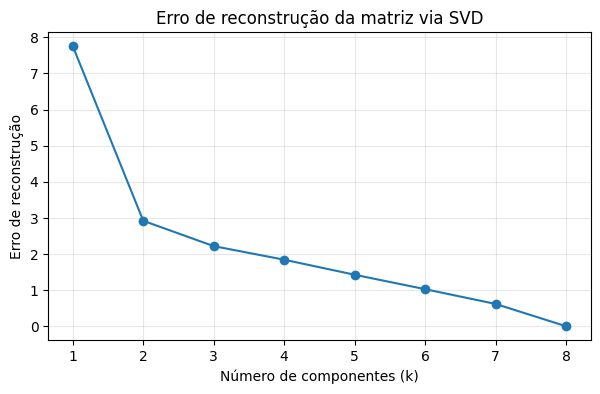

In [11]:
def reconstruir(U, S, Vt, k):
    """Reconstrói a matriz utilizando os k primeiros componentes da SVD."""

    Uk = U[:, :k]
    Sigma = np.diag(S[:k])
    Vtk = Vt[:k, :]

    return Uk @ Sigma @ Vtk


# Cálculo do erro de reconstrução para diferentes valores de k
erros = []

for k in range(1, len(S) + 1):
    Rk = reconstruir(U, S, Vt, k)

    erro = np.linalg.norm(R_grande - Rk)
    erros.append(erro)

    print(f"k={k}: erro de reconstrução = {erro:.3f}")


# Visualização da relação entre dimensionalidade e erro
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(S) + 1),
    erros,
    "o-"
)

plt.xlabel("Número de componentes (k)")
plt.ylabel("Erro de reconstrução")
plt.title("Erro de reconstrução da matriz via SVD")
plt.grid(alpha=0.3)

plt.show()

### 📊 Análise do Erro de Reconstrução

O erro de reconstrução diminui progressivamente à medida que mais componentes da SVD são utilizados.

A redução mais significativa ocorre entre **1 e 2 componentes**, quando o erro cai de aproximadamente **7,754 para 2,919**.

Esse comportamento está alinhado com a análise anterior, na qual os dois primeiros componentes concentraram aproximadamente **96,5% da energia total da matriz**.

A partir de `k = 2`, a inclusão de novos componentes continua reduzindo o erro, porém com ganhos progressivamente menores.

Quando todos os **8 componentes** são utilizados (`k = 8`), o erro de reconstrução chega a aproximadamente **0**, indicando que a matriz original é reconstruída integralmente.

### 💡 Relação entre Compressão e Precisão

A reconstrução com poucos componentes demonstra o compromisso entre **redução de dimensionalidade** e **fidelidade da representação**.

Neste conjunto de dados, utilizar apenas **2 dos 8 componentes** preserva aproximadamente **96,5% da energia da matriz**, embora ainda exista algum erro de reconstrução.

Isso demonstra como a SVD pode reduzir a dimensionalidade dos dados mantendo grande parte de sua estrutura relevante — princípio importante em técnicas de compressão, análise de dados e sistemas de recomendação.


Derivadas e Gradiente Descendente 📉

O **gradiente descendente** é um método de otimização utilizado para minimizar funções de erro em diversos modelos de Machine Learning.

A cada iteração, o algoritmo atualiza o valor do parâmetro na direção oposta ao gradiente da função:

\[
x_{\text{novo}} = x_{\text{atual}} - \alpha \cdot f'(x_{\text{atual}})
\]

onde \(\alpha\) representa a **taxa de aprendizado**, responsável por controlar o tamanho de cada passo durante o processo de otimização.

Para demonstrar o funcionamento do algoritmo, será utilizada a função:

\[
f(x) = (x - 3)^2
\]

Sua derivada é:

\[
f'(x) = 2(x - 3)
\]

A função possui mínimo global em \(x = 3\). O objetivo da demonstração é observar como o gradiente descendente converge iterativamente para esse ponto.

Após 30 iterações, x = 2.9901
Primeiros 6 pontos: [-5.    -3.4   -2.12  -1.096 -0.277  0.379]
Últimos 3 pontos: [2.985 2.988 2.99 ]


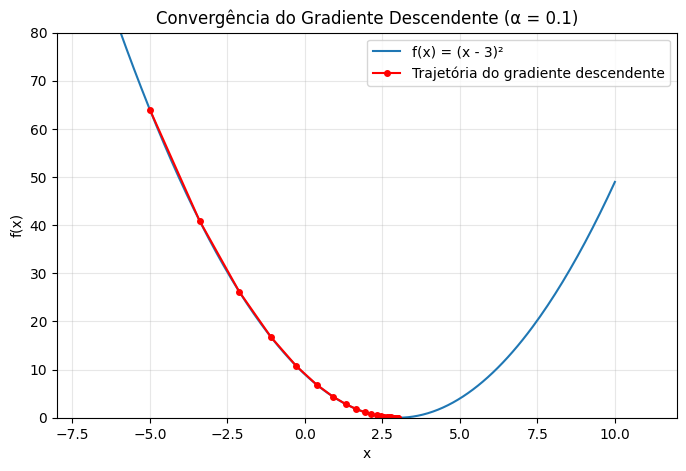

In [12]:
# Função objetivo
def f(x):
    return (x - 3)**2

# Derivada da função
def derivada_f(x):
    return 2 * (x - 3)


# Configuração do gradiente descendente
alpha = 0.1        # taxa de aprendizado
x = -5.0           # ponto inicial
caminho = [x]


# Processo iterativo de otimização
for passo in range(30):
    x = x - alpha * derivada_f(x)
    caminho.append(x)


# Resultados da convergência
print(f"Após 30 iterações, x = {x:.4f}")
print("Primeiros 6 pontos:", np.round(caminho[:6], 3))
print("Últimos 3 pontos:", np.round(caminho[-3:], 3))


# Visualização do processo de otimização
xs = np.linspace(-6, 10, 200)

plt.figure(figsize=(8, 5))

plt.plot(
    xs,
    f(xs),
    label="f(x) = (x - 3)²"
)

plt.plot(
    caminho,
    [f(c) for c in caminho],
    "ro-",
    ms=4,
    label="Trajetória do gradiente descendente"
)

plt.xlim(-8, 12)
plt.ylim(0, 80)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(f"Convergência do Gradiente Descendente (α = {alpha})")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 📊 Análise da Convergência

O gradiente descendente foi iniciado em \(x=-5\), um ponto distante do mínimo da função, utilizando uma taxa de aprendizado de \(\alpha=0.1\).

Ao longo de **30 iterações**, o algoritmo atualizou progressivamente o valor de \(x\) na direção oposta ao gradiente. Os últimos valores obtidos foram aproximadamente:

\[
2.985 \rightarrow 2.988 \rightarrow 2.990
\]

Esses resultados mostram a convergência progressiva para \(x=3\), que corresponde ao **mínimo global** da função:

\[
f(x)=(x-3)^2
\]

O gráfico evidencia que os passos são maiores no início da otimização e tornam-se progressivamente menores à medida que o algoritmo se aproxima do ponto mínimo.

### 💡 Relação com Machine Learning

O mesmo princípio é utilizado no treinamento de diversos modelos de Machine Learning: os parâmetros são ajustados iterativamente com o objetivo de minimizar uma **função de perda**.

A **taxa de aprendizado** controla o tamanho dessas atualizações. Valores adequados favorecem uma convergência estável, enquanto valores muito elevados podem provocar oscilações ou até impedir a convergência.

Este exemplo demonstra, de forma simplificada, o mecanismo matemático fundamental utilizado em diversos processos de otimização em Inteligência Artificial.


### Treinamento de um Modelo com Gradiente Descendente 🎓
 Nesta etapa, o gradiente descendente é aplicado ao treinamento de um modelo simples de regressão.
O objetivo é encontrar o parâmetro \(w\) da função:
\[
y = w \cdot x
\]
que melhor representa a relação entre uma característica do filme e a avaliação atribuída pelo usuário.
O treinamento busca minimizar o Erro Quadrático Médio (MSE):
\[
L(w)=\frac{1}{n}\sum_i(wx_i-y_i)^2
\]
utilizando seu gradiente:
\[
L'(w)=\frac{2}{n}\sum_i(wx_i-y_i)x_i
\]
A cada iteração, o parâmetro \(w\) é atualizado na direção que reduz a função de perda.

w aprendido = 4.334
w verdadeiro = 4.2


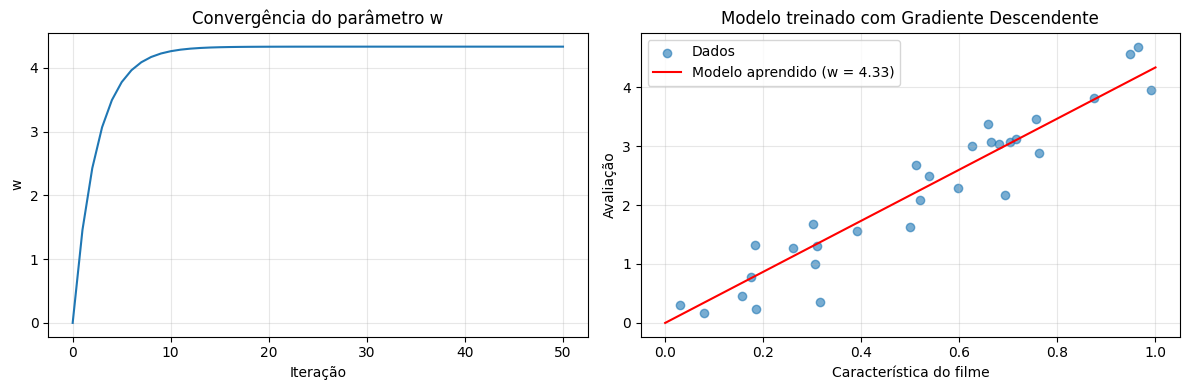

In [13]:
# Geração de dados sintéticos
# x representa a intensidade de uma característica do filme
# y representa a avaliação atribuída pelo usuário
x_dados = np.random.rand(30)

w_verdadeiro = 4.2

y_dados = (
    w_verdadeiro * x_dados
    + np.random.normal(0, 0.3, 30)
)


# Gradiente da função de perda
def gradiente_L(w):
    return (2 / len(x_dados)) * np.sum(
        (w * x_dados - y_dados) * x_dados
    )


# Inicialização do treinamento
w = 0.0
alpha = 0.5
historico_w = [w]


# Otimização por gradiente descendente
for passo in range(50):
    w = w - alpha * gradiente_L(w)
    historico_w.append(w)


print(f"w aprendido = {w:.3f}")
print(f"w verdadeiro = {w_verdadeiro}")


# Visualização do treinamento
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

# Evolução do parâmetro w
a1.plot(historico_w)
a1.set_title("Convergência do parâmetro w")
a1.set_xlabel("Iteração")
a1.set_ylabel("w")
a1.grid(alpha=0.3)


# Dados e modelo aprendido
a2.scatter(
    x_dados,
    y_dados,
    alpha=0.6,
    label="Dados"
)

xs = np.linspace(0, 1, 100)

a2.plot(
    xs,
    w * xs,
    "r-",
    label=f"Modelo aprendido (w = {w:.2f})"
)

a2.set_xlabel("Característica do filme")
a2.set_ylabel("Avaliação")
a2.set_title("Modelo treinado com Gradiente Descendente")
a2.legend()
a2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análise do Treinamento

O modelo foi treinado utilizando **gradiente descendente** para estimar o parâmetro \(w\) a partir dos dados sintéticos.

O valor utilizado na geração dos dados foi:

\[
w_{\text{verdadeiro}} = 4.2
\]

Após **50 iterações**, o algoritmo estimou:

\[
w_{\text{aprendido}} \approx 4.334
\]

A proximidade entre os dois valores indica que o processo de otimização conseguiu recuperar adequadamente a relação existente entre a característica do filme e a avaliação do usuário.

O gráfico de convergência mostra que o parâmetro \(w\) parte de zero, sofre ajustes maiores nas primeiras iterações e gradualmente se estabiliza próximo do valor que minimiza a função de perda.

No segundo gráfico, a reta obtida pelo modelo acompanha a tendência dos dados observados. As diferenças entre alguns pontos e a reta são esperadas, pois foi adicionado **ruído aleatório** aos dados durante sua geração.

### 💡 Interpretação

Este experimento demonstra o processo básico de treinamento de um modelo de Machine Learning:

1. inicialização de um parâmetro;
2. cálculo do erro;
3. cálculo do gradiente;
4. atualização do parâmetro;
5. repetição do processo até a convergência.

O exemplo conecta o conceito matemático de **derivadas** ao processo computacional de **otimização de modelos**, mostrando como o gradiente descendente pode aprender parâmetros diretamente a partir dos dados.

---
Métodos Numéricos: Aproximação de Derivadas 🧮

Em problemas computacionais, nem sempre é conveniente ou possível obter uma derivada analiticamente. Uma alternativa é aproximá-la numericamente utilizando diferenças finitas.
Para um valor suficientemente pequeno de \(h\), a derivada pode ser aproximada pela diferença entre valores próximos da função.

$$f'(x) \approx \frac{f(x + h) - f(x)}{h} \qquad \text{para } h \text{ pequeno}$$

In [15]:
def derivada_numerica(f, x, h):
    """Aproxima a derivada de f em x utilizando diferenças finitas."""
    return (f(x + h) - f(x)) / h


x0 = 5.0

# Valor obtido pela derivada analítica
exata = derivada_f(x0)

print(f"Derivada exata em x=5: {exata}")
print(f"{'h':>12} | {'aproximação':>12} | {'erro':>12}")

for h in [1, 0.1, 0.01, 1e-4, 1e-8, 1e-12]:
    aprox = derivada_numerica(f, x0, h)
    erro = abs(aprox - exata)

    print(f"{h:>12.0e} | {aprox:>12.6f} | {erro:>12.2e}")

Derivada exata em x=5: 4.0
           h |  aproximação |         erro
       1e+00 |     5.000000 |     1.00e+00
       1e-01 |     4.100000 |     1.00e-01
       1e-02 |     4.010000 |     1.00e-02
       1e-04 |     4.000100 |     1.00e-04
       1e-08 |     4.000000 |     2.43e-08
       1e-12 |     4.000356 |     3.56e-04


### 📊 Análise da Aproximação Numérica

A derivada analítica da função em \(x=5\) é:

\[
f'(5)=4
\]

Utilizando diferenças finitas, observa-se que a aproximação melhora progressivamente à medida que \(h\) diminui.

Para \(h=10^{-4}\), por exemplo, a aproximação obtida foi **4,000100**, enquanto para \(h=10^{-8}\) o erro caiu para aproximadamente \(2,43\times10^{-8}\).

Entretanto, reduzir \(h\) indefinidamente não garante maior precisão. Quando \(h=10^{-12}\), o erro aumentou para aproximadamente \(3,56\times10^{-4}\).

### ⚠️ Precisão Numérica e Ponto Flutuante

Esse comportamento ocorre devido às limitações da representação de números em **ponto flutuante**.

Quando \(h\) é extremamente pequeno, os valores \(f(x+h)\) e \(f(x)\) tornam-se numericamente muito próximos. A subtração desses valores pode provocar perda de precisão, fenômeno associado ao **cancelamento numérico**.

Como o resultado dessa diferença ainda é dividido por um número muito pequeno, o erro de arredondamento pode ser amplificado.

O experimento demonstra um princípio importante da computação numérica: **diminuir o tamanho do passo nem sempre aumenta a precisão**. Existe um equilíbrio entre o erro da aproximação matemática e os erros introduzidos pela precisão finita do computador.

Integração Numérica pelo Método dos Trapézios 📐

Enquanto a derivada descreve a taxa de variação de uma função, a integral permite calcular uma quantidade acumulada ao longo de um intervalo.
Quando uma solução analítica não está disponível ou não é conveniente, a integral pode ser aproximada numericamente. Um dos métodos mais conhecidos é a regra dos trapézios, que divide o intervalo em subintervalos e aproxima a área sob a curva pela soma das áreas de trapézios.

$$\int_a^b f(x)\,dx \;\approx\; h\left[\frac{f(x_0)}{2} + f(x_1) + f(x_2) + \dots + f(x_{n-1}) + \frac{f(x_n)}{2}\right], \qquad h = \frac{b-a}{n}$$

Para avaliar a precisão do método, será utilizada novamente a função \(f(x)=(x-3)^2\), cuja integral exata no intervalo \([0,3]\) é igual a 9.

       n |  aproximação |         erro
       1 |    13.500000 |     4.50e+00
       2 |    10.125000 |     1.12e+00
       4 |     9.281250 |     2.81e-01
       8 |     9.070312 |     7.03e-02
      16 |     9.017578 |     1.76e-02
      64 |     9.001099 |     1.10e-03
     256 |     9.000069 |     6.87e-05
    1024 |     9.000004 |     4.29e-06


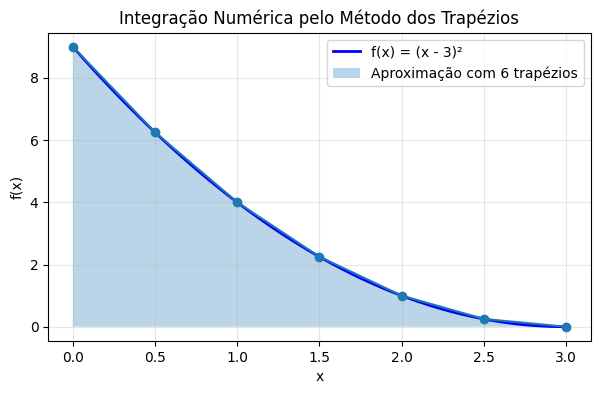

In [16]:
def integral_trapezio(f, a, b, n):
    """Aproxima a integral de f entre a e b utilizando n trapézios."""

    xs = np.linspace(a, b, n + 1)
    h = (b - a) / n

    # Contribuição dos extremos do intervalo
    soma_pontas = (f(xs[0]) + f(xs[-1])) / 2

    # Contribuição dos pontos internos
    soma_meio = np.sum(f(xs[1:-1]))

    return h * (soma_pontas + soma_meio)


# Valor exato da integral no intervalo [0, 3]
exata_integral = 9.0

print(f"{'n':>8} | {'aproximação':>12} | {'erro':>12}")

for n in [1, 2, 4, 8, 16, 64, 256, 1024]:
    aprox = integral_trapezio(f, 0, 3, n)
    erro = abs(aprox - exata_integral)

    print(f"{n:>8} | {aprox:>12.6f} | {erro:>12.2e}")


# Visualização da aproximação com 6 trapézios
n = 6

xs_t = np.linspace(0, 3, n + 1)
xs_f = np.linspace(0, 3, 200)

plt.figure(figsize=(7, 4))

plt.plot(
    xs_f,
    f(xs_f),
    "b-",
    lw=2,
    label="f(x) = (x - 3)²"
)

plt.fill_between(
    xs_t,
    f(xs_t),
    alpha=0.3,
    label=f"Aproximação com {n} trapézios"
)

plt.plot(
    xs_t,
    f(xs_t),
    "o-"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Integração Numérica pelo Método dos Trapézios")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 📊 Análise da Integração Numérica

A integral exata da função \(f(x)=(x-3)^2\) no intervalo \([0,3]\) é:

\[
\int_0^3 (x-3)^2\,dx = 9
\]

A aplicação do **método dos trapézios** mostra que a aproximação converge progressivamente para esse valor à medida que o número de subdivisões do intervalo aumenta.

Com apenas **2 trapézios**, a aproximação obtida foi **10,125**, apresentando um erro de aproximadamente **1,12**.

Ao aumentar o número de subdivisões, o erro diminui significativamente. Com **1024 trapézios**, a aproximação obtida foi aproximadamente **9,000004**, com erro da ordem de \(10^{-6}\).

### 💡 Interpretação

O comportamento observado demonstra que aumentar o número de subdivisões permite que os segmentos utilizados pelo método representem melhor a curvatura da função.

O gráfico apresenta visualmente essa aproximação: os trapézios representam uma estimativa discreta da área sob a curva.

Este experimento demonstra como métodos numéricos permitem aproximar integrais utilizando operações computacionais simples, sendo especialmente úteis quando uma solução analítica é difícil ou inviável de obter.

## 🎯 Conclusão do Projeto

Este projeto demonstrou, de forma prática, como conceitos matemáticos fundamentais estão diretamente relacionados ao desenvolvimento de sistemas de Inteligência Artificial e Machine Learning.

A construção do recomendador de filmes permitiu explorar diferentes etapas e conceitos, incluindo:

- **Vetores e matrizes** para representação dos dados;
- **Produto interno e similaridade por cosseno** para comparação entre usuários;
- **Transformações lineares** para compreender operações matriciais;
- **Decomposição em Valores Singulares (SVD)** para identificação de padrões latentes;
- **Redução de dimensionalidade** e análise do erro de reconstrução;
- **Derivadas e gradiente descendente** para otimização de parâmetros;
- **Treinamento de um modelo** por minimização do erro;
- **Diferenças finitas** para aproximação numérica de derivadas;
- **Integração numérica pelo método dos trapézios** para aproximação de áreas.

### 🤖 Relação com Inteligência Artificial

Os experimentos realizados mostram que diversos mecanismos utilizados em Inteligência Artificial podem ser compreendidos a partir de fundamentos matemáticos.

A similaridade entre vetores permite identificar usuários com preferências semelhantes; a SVD possibilita encontrar estruturas latentes e reduzir a dimensionalidade dos dados; e o gradiente descendente permite ajustar parâmetros de um modelo através da minimização de uma função de erro.

Além disso, os experimentos com derivação e integração numérica demonstram a importância da precisão computacional e dos métodos de aproximação na resolução de problemas matemáticos por computador.

### 🚀 Resultado

Ao final do projeto foi possível implementar e analisar um sistema de recomendação didático, conectando conceitos de **Álgebra Linear, Cálculo, Métodos Numéricos, Python e Machine Learning**.

O projeto reforça como a matemática fornece a base para compreender não apenas como utilizar algoritmos de Inteligência Artificial, mas também os princípios que explicam seu funcionamento.

---

**Autor:** Ronildo Batista do Nascimento  
**Tecnologias:** Python • NumPy • Matplotlib • Google Colab  
**Área:** Inteligência Artificial • Machine Learning • Matemática Computacional